# Early Development Data Programming and Exploratory Outputs

This notebook converts the provided script workflow into a single runnable Jupyter notebook. It simulates clinical, biomarker, and PK data, builds an analysis-ready dataset, generates summary tables and figures, and fits exploratory machine learning models.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Optional imports from the original script block
try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
except Exception:
    KaplanMeierFitter = None
    CoxPHFitter = None


## 1. Setup

In [7]:
SEED = 42
np.random.seed(SEED)

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DIR = os.path.join(BASE_DIR, "data_processed")
FIG_DIR = os.path.join(BASE_DIR, "outputs", "figures")
TABLE_DIR = os.path.join(BASE_DIR, "outputs", "tables")
MODEL_DIR = os.path.join(BASE_DIR, "outputs", "models")

for p in [DATA_DIR, PROCESSED_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(p, exist_ok=True)

N_PATIENTS = 120
DOSE_LEVELS = [25, 50, 100, 200]
TIMEPOINTS = np.array([0, 1, 2, 4, 8, 24, 48, 72], dtype=float)


## 2. Data simulation functions

In [9]:
def assign_dose_group(dose: int) -> str:
    if dose in [25, 50]:
        return "Low"
    if dose == 100:
        return "Medium"
    return "High"


def simulate_clinical_data(n_patients: int) -> pd.DataFrame:
    patient_ids = [f"P{i:03d}" for i in range(1, n_patients + 1)]
    dose_mg = np.random.choice(DOSE_LEVELS, size=n_patients, p=[0.20, 0.25, 0.30, 0.25])
    dose_group = [assign_dose_group(d) for d in dose_mg]

    age = np.random.randint(32, 83, size=n_patients)
    sex = np.random.choice(["Male", "Female"], size=n_patients)
    ecog = np.random.choice([0, 1, 2], size=n_patients, p=[0.35, 0.45, 0.20])

    tumor_baseline = np.clip(np.random.normal(loc=95, scale=28, size=n_patients), 40, 180)

    clinical = pd.DataFrame(
        {
            "Patient_ID": patient_ids,
            "Dose_mg": dose_mg,
            "Dose_Group": dose_group,
            "Age": age,
            "Sex": sex,
            "ECOG": ecog,
            "Tumor_Baseline_mm": np.round(tumor_baseline, 1),
        }
    )
    return clinical


def simulate_biomarker_data(clinical_df: pd.DataFrame) -> pd.DataFrame:
    n_patients = clinical_df.shape[0]
    patient_ids = clinical_df["Patient_ID"].tolist()

    mutation_status = np.random.choice(["Mutant", "Wildtype"], size=n_patients, p=[0.40, 0.60])

    ldh = np.clip(np.random.lognormal(mean=np.log(220), sigma=0.45, size=n_patients), 120, 650)
    crp = np.clip(np.random.lognormal(mean=np.log(10), sigma=0.9, size=n_patients), 1, 90)
    glucose = np.clip(np.random.normal(loc=102, scale=18, size=n_patients), 70, 180)
    lactate = np.clip(np.random.normal(loc=2.0, scale=0.8, size=n_patients), 0.8, 5.5)
    ctdna = np.clip(np.random.beta(a=1.5, b=8.0, size=n_patients) * 0.60, 0.001, 0.40)

    biomarker_response_score = (
        0.8 * (ldh - np.mean(ldh)) / np.std(ldh)
        + 0.7 * (crp - np.mean(crp)) / np.std(crp)
        + 0.9 * (ctdna - np.mean(ctdna)) / np.std(ctdna)
        + np.random.normal(0, 0.4, n_patients)
    )

    biomarkers = pd.DataFrame(
        {
            "Patient_ID": patient_ids,
            "LDH_U_L": np.round(ldh, 1),
            "CRP_mg_L": np.round(crp, 1),
            "Glucose_mg_dL": np.round(glucose, 1),
            "Lactate_mmol_L": np.round(lactate, 2),
            "ctDNA_fraction": np.round(ctdna, 4),
            "Mutation_Status": mutation_status,
            "Biomarker_Response_Score": np.round(biomarker_response_score, 3),
        }
    )
    return biomarkers


def simulate_pk_data(clinical_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in clinical_df.iterrows():
        patient_id = row["Patient_ID"]
        dose = row["Dose_mg"]

        scale_factor = np.random.lognormal(mean=0.0, sigma=0.20)
        kel = np.clip(np.random.normal(loc=0.055, scale=0.012), 0.025, 0.10)
        ka_shape = np.clip(np.random.normal(loc=1.8, scale=0.25), 1.1, 2.4)

        base_cmax = dose * np.random.uniform(6.0, 9.5)

        for t in TIMEPOINTS:
            if t == 0:
                conc = 0.0
            else:
                rise = (t ** ka_shape) * np.exp(-0.55 * t)
                rise_norm = rise / np.max([(x ** ka_shape) * np.exp(-0.55 * x) for x in TIMEPOINTS[1:]])
                conc = base_cmax * rise_norm * np.exp(-kel * max(t - 4, 0)) * scale_factor
                conc += np.random.normal(0, dose * 0.7)

            conc = max(conc, 0.0)
            rows.append(
                {
                    "Patient_ID": patient_id,
                    "Time_hr": float(t),
                    "Drug_Concentration_ng_mL": round(conc, 2),
                }
            )

    pk_df = pd.DataFrame(rows)
    return pk_df


def inject_clinical_endpoints(clinical_df: pd.DataFrame, biomarker_df: pd.DataFrame) -> pd.DataFrame:
    df = clinical_df.merge(biomarker_df, on="Patient_ID", how="left").copy()

    dose_effect = df["Dose_mg"].map({25: -0.03, 50: -0.08, 100: -0.16, 200: -0.24}).values
    biomarker_penalty = (
        0.00035 * df["LDH_U_L"].values
        + 0.0045 * df["CRP_mg_L"].values
        + 0.90 * df["ctDNA_fraction"].values
    )

    mutation_bonus = np.where(df["Mutation_Status"].values == "Mutant", -0.04, 0.00)
    ecog_penalty = 0.06 * df["ECOG"].values
    noise = np.random.normal(0, 0.12, df.shape[0])

    progression_ratio = 0.18 + biomarker_penalty + ecog_penalty + noise + dose_effect + mutation_bonus
    tumor_week6 = df["Tumor_Baseline_mm"].values * (1 + progression_ratio)
    tumor_week6 = np.clip(tumor_week6, 10, 250)

    tumor_change_pct = ((tumor_week6 - df["Tumor_Baseline_mm"].values) / df["Tumor_Baseline_mm"].values) * 100

    bor = []
    for x in tumor_change_pct:
        if x <= -100:
            bor.append("CR")
        elif x <= -30:
            bor.append("PR")
        elif x < 20:
            bor.append("SD")
        else:
            bor.append("PD")

    severe_ae_prob = (
        0.05
        + 0.00012 * df["LDH_U_L"].values
        + df["Dose_mg"].values / 2200
        + 0.05 * df["ECOG"].values
    )
    severe_ae_prob = np.clip(severe_ae_prob, 0.05, 0.65)

    ae_grade = []
    serious_ae = []
    discontinued = []

    for p in severe_ae_prob:
        r = np.random.rand()
        if r < p * 0.25:
            grade = 4
        elif r < p:
            grade = 3
        elif r < 0.60:
            grade = 2
        else:
            grade = 1
        ae_grade.append(grade)

        sae = int((grade >= 3) and (np.random.rand() < 0.45))
        disc = int((grade >= 3 and np.random.rand() < 0.35) or (np.random.rand() < 0.05))
        serious_ae.append(sae)
        discontinued.append(disc)

    linear_risk = (
        0.0030 * df["LDH_U_L"].values
        + 0.035 * df["CRP_mg_L"].values
        + 3.2 * df["ctDNA_fraction"].values
        + 0.30 * df["ECOG"].values
        - df["Dose_mg"].values / 240
        + np.where(np.array(bor) == "PR", -1.0, 0.0)
        + np.where(np.array(bor) == "CR", -1.5, 0.0)
        + np.where(np.array(bor) == "PD", 0.8, 0.0)
    )

    base_survival = 330 - (linear_risk * 40) + np.random.normal(0, 50, df.shape[0])
    survival_time = np.clip(base_survival, 30, 540)

    event_prob = 1 / (1 + np.exp(-(linear_risk - 1.8)))
    event_prob = np.clip(event_prob, 0.10, 0.95)
    event = (np.random.rand(df.shape[0]) < event_prob).astype(int)

    out = clinical_df.copy()
    out["Tumor_Week6_mm"] = np.round(tumor_week6, 1)
    out["Survival_Time_days"] = np.round(survival_time, 1)
    out["Event"] = event
    out["Best_Overall_Response"] = bor
    out["Adverse_Event_Grade"] = ae_grade
    out["Serious_AE"] = serious_ae
    out["Discontinued"] = discontinued

    return out


## 3. Simulate and save raw datasets

In [11]:
clinical_base = simulate_clinical_data(N_PATIENTS)
biomarker = simulate_biomarker_data(clinical_base)
clinical = inject_clinical_endpoints(clinical_base, biomarker)
pk = simulate_pk_data(clinical)

clinical.to_csv(os.path.join(DATA_DIR, "raw_clinical_data.csv"), index=False)
biomarker.to_csv(os.path.join(DATA_DIR, "raw_biomarker_data.csv"), index=False)
pk.to_csv(os.path.join(DATA_DIR, "raw_pk_data.csv"), index=False)

print("Raw datasets saved.")
clinical.head(), biomarker.head(), pk.head()


Raw datasets saved.


(  Patient_ID  Dose_mg Dose_Group  Age     Sex  ECOG  Tumor_Baseline_mm  \
 0       P001       50        Low   59  Female     0              107.6   
 1       P002      200       High   56  Female     0               92.8   
 2       P003      100     Medium   70  Female     0               40.0   
 3       P004      100     Medium   64  Female     2              133.9   
 4       P005       25        Low   32  Female     0              147.4   
 
    Tumor_Week6_mm  Survival_Time_days  Event Best_Overall_Response  \
 0           113.4               319.4      1                    SD   
 1            87.6               288.8      0                    SD   
 2            37.4               301.5      0                    SD   
 3           197.8               217.8      1                    PD   
 4           217.8               132.6      1                    PD   
 
    Adverse_Event_Grade  Serious_AE  Discontinued  
 0                    3           0             1  
 1              

## 4. Build analysis-ready dataset

In [13]:
def trapezoidal_auc(time_values: np.ndarray, conc_values: np.ndarray) -> float:
    order = np.argsort(time_values)
    t = time_values[order]
    c = conc_values[order]
    return float(np.trapezoid(c, t))


def compute_pk_summary(pk_df: pd.DataFrame) -> pd.DataFrame:
    summaries = []

    for patient_id, grp in pk_df.groupby("Patient_ID"):
        t = grp["Time_hr"].values.astype(float)
        c = grp["Drug_Concentration_ng_mL"].values.astype(float)

        auc_0_72 = trapezoidal_auc(t, c)
        cmax = float(np.max(c))
        tmax = float(t[np.argmax(c)])

        summaries.append(
            {
                "Patient_ID": patient_id,
                "AUC_0_72": round(auc_0_72, 2),
                "Cmax": round(cmax, 2),
                "Tmax_hr": round(tmax, 2),
            }
        )

    return pd.DataFrame(summaries)


pk_summary = compute_pk_summary(pk)

analysis = clinical.merge(biomarker, on="Patient_ID", how="left")
analysis = analysis.merge(pk_summary, on="Patient_ID", how="left")

analysis["Tumor_Change_Pct"] = (
    (analysis["Tumor_Week6_mm"] - analysis["Tumor_Baseline_mm"])
    / analysis["Tumor_Baseline_mm"]
    * 100
).round(2)

analysis["Responder"] = (analysis["Tumor_Change_Pct"] <= -30).astype(int)
analysis["High_LDH"] = (analysis["LDH_U_L"] > analysis["LDH_U_L"].median()).astype(int)
analysis["High_CRP"] = (analysis["CRP_mg_L"] > analysis["CRP_mg_L"].median()).astype(int)
analysis["Clinical_Benefit"] = (
    (analysis["Responder"] == 1)
    | (analysis["Best_Overall_Response"].isin(["SD", "PR", "CR"]))
).astype(int)

analysis["AE_Grade3Plus"] = (analysis["Adverse_Event_Grade"] >= 3).astype(int)

cols_order = [
    "Patient_ID","Dose_mg","Dose_Group","Age","Sex","ECOG",
    "Tumor_Baseline_mm","Tumor_Week6_mm","Tumor_Change_Pct","Responder",
    "Best_Overall_Response","Clinical_Benefit","Survival_Time_days","Event",
    "Adverse_Event_Grade","AE_Grade3Plus","Serious_AE","Discontinued",
    "LDH_U_L","CRP_mg_L","Glucose_mg_dL","Lactate_mmol_L","ctDNA_fraction",
    "Mutation_Status","Biomarker_Response_Score","AUC_0_72","Cmax","Tmax_hr",
    "High_LDH","High_CRP",
]
analysis = analysis[cols_order]
analysis.to_csv(os.path.join(PROCESSED_DIR, "analysis_dataset.csv"), index=False)

analysis.head()


,Patient_ID,Dose_mg,Dose_Group,Age,Sex,ECOG,Tumor_Baseline_mm,Tumor_Week6_mm,Tumor_Change_Pct,Responder,...,Glucose_mg_dL,Lactate_mmol_L,ctDNA_fraction,Mutation_Status,Biomarker_Response_Score,AUC_0_72,Cmax,Tmax_hr,High_LDH,High_CRP
0,P001,50,Low,59,Female,0,107.6,113.4,5.39,0,...,70.0,2.10,0.1007,Mutant,-1.241,3103.25,308.80,4.0,0,0
1,P002,200,High,56,Female,0,92.8,87.6,-5.60,0,...,84.2,2.18,0.0982,Mutant,-0.773,19449.11,1755.11,4.0,1,0
2,P003,100,Medium,70,Female,0,40.0,37.4,-6.50,0,...,104.6,1.23,0.2646,Mutant,0.313,8944.68,901.96,4.0,0,0
3,P004,100,Medium,64,Female,2,133.9,197.8,47.72,0,...,98.0,1.32,0.0637,Mutant,0.365,11451.28,595.96,4.0,0,1
4,P005,25,Low,32,Female,0,147.4,217.8,47.76,0,...,116.8,2.04,0.2886,Wildtype,1.024,2027.89,217.56,4.0,0,0


## 5. Generate summary tables

In [15]:
def build_summary_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby("Dose_Group")
        .apply(
            lambda x: pd.Series(
                {
                    "N": x.shape[0],
                    "Mean_Age": round(x["Age"].mean(), 1),
                    "Female_%": round((x["Sex"] == "Female").mean() * 100, 1),
                    "Mean_Baseline_Tumor_mm": round(x["Tumor_Baseline_mm"].mean(), 1),
                    "Responder_Rate_%": round(x["Responder"].mean() * 100, 1),
                    "Median_Survival_days": round(x["Survival_Time_days"].median(), 1),
                    "Mean_LDH_U_L": round(x["LDH_U_L"].mean(), 1),
                    "Mean_CRP_mg_L": round(x["CRP_mg_L"].mean(), 1),
                    "Grade3Plus_AE_Rate_%": round(x["AE_Grade3Plus"].mean() * 100, 1),
                    "Serious_AE_Rate_%": round(x["Serious_AE"].mean() * 100, 1),
                    "Discontinuation_Rate_%": round(x["Discontinued"].mean() * 100, 1),
                }
            )
        )
        .reset_index()
    )
    dose_order = {"Low": 0, "Medium": 1, "High": 2}
    summary["SortOrder"] = summary["Dose_Group"].map(dose_order)
    summary = summary.sort_values("SortOrder").drop(columns=["SortOrder"])
    return summary


def build_patient_listing(df: pd.DataFrame) -> pd.DataFrame:
    listing_cols = [
        "Patient_ID","Dose_Group","Dose_mg","Tumor_Change_Pct","Best_Overall_Response",
        "Responder","Clinical_Benefit","Survival_Time_days","Event","LDH_U_L",
        "CRP_mg_L","ctDNA_fraction","AUC_0_72","Cmax","Adverse_Event_Grade","Serious_AE",
    ]
    return df[listing_cols].sort_values(["Dose_mg", "Patient_ID"]).reset_index(drop=True)


summary_table = build_summary_table(analysis)
patient_listing = build_patient_listing(analysis)

summary_table.to_csv(os.path.join(TABLE_DIR, "summary_table.csv"), index=False)
patient_listing.to_csv(os.path.join(TABLE_DIR, "patient_listing.csv"), index=False)

summary_table


/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_20404/110638243.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Dose_Group,N,Mean_Age,Female_%,Mean_Baseline_Tumor_mm,Responder_Rate_%,Median_Survival_days,Mean_LDH_U_L,Mean_CRP_mg_L,Grade3Plus_AE_Rate_%,Serious_AE_Rate_%,Discontinuation_Rate_%
1,Low,58.0,54.4,58.6,95.1,0.0,229.8,258.9,14.1,10.3,6.9,17.2
2,Medium,31.0,56.0,51.6,78.5,0.0,249.8,284.1,13.6,12.9,9.7,16.1
0,High,31.0,58.0,51.6,104.8,0.0,283.1,234.8,24.1,9.7,3.2,9.7


## 6. Exploratory visualizations

In [17]:
def save_waterfall_plot(df: pd.DataFrame, out_path: str) -> None:
    plot_df = df.sort_values("Tumor_Change_Pct").reset_index(drop=True)
    plt.figure(figsize=(12, 6))
    plt.bar(range(plot_df.shape[0]), plot_df["Tumor_Change_Pct"])
    plt.axhline(-30, linestyle="--", linewidth=1)
    plt.axhline(20, linestyle="--", linewidth=1)
    plt.xlabel("Patients sorted by tumor change")
    plt.ylabel("Tumor change from baseline (%)")
    plt.title("Waterfall Plot of Tumor Response")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def compute_km_curve(times: np.ndarray, events: np.ndarray):
    order = np.argsort(times)
    times = times[order]
    events = events[order]

    unique_event_times = np.sort(np.unique(times[events == 1]))
    survival = 1.0
    km_times = [0.0]
    km_surv = [1.0]

    for t in unique_event_times:
        at_risk = np.sum(times >= t)
        d = np.sum((times == t) & (events == 1))
        if at_risk > 0:
            survival *= (1 - d / at_risk)
            km_times.append(t)
            km_surv.append(survival)

    return km_times, km_surv


def save_km_plot(df: pd.DataFrame, out_path: str) -> None:
    plt.figure(figsize=(8, 6))
    groups = [("Low", df[df["Dose_Group"] == "Low"]),
              ("Medium", df[df["Dose_Group"] == "Medium"]),
              ("High", df[df["Dose_Group"] == "High"])]
    for label, grp in groups:
        if grp.empty:
            continue
        times, surv = compute_km_curve(grp["Survival_Time_days"].values, grp["Event"].values)
        plt.step(times, surv, where="post", label=label)

    plt.xlabel("Time (days)")
    plt.ylabel("Survival probability")
    plt.title("Kaplan-Meier Style Survival Curve by Dose Group")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def save_biomarker_vs_tumor_plot(df: pd.DataFrame, out_path: str) -> None:
    plt.figure(figsize=(8, 6))
    plt.scatter(df["LDH_U_L"], df["Tumor_Change_Pct"], alpha=0.8)
    z = np.polyfit(df["LDH_U_L"], df["Tumor_Change_Pct"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df["LDH_U_L"].min(), df["LDH_U_L"].max(), 100)
    plt.plot(x_line, p(x_line), linewidth=2)
    plt.xlabel("Baseline LDH (U/L)")
    plt.ylabel("Tumor change from baseline (%)")
    plt.title("Baseline LDH vs Tumor Change")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def save_pk_profiles(pk_df: pd.DataFrame, clinical_df: pd.DataFrame, out_path: str) -> None:
    merged = pk_df.merge(clinical_df[["Patient_ID", "Dose_Group"]], on="Patient_ID", how="left")
    plt.figure(figsize=(8, 6))
    for dose_group in ["Low", "Medium", "High"]:
        grp = merged[merged["Dose_Group"] == dose_group]
        if grp.empty:
            continue
        mean_profile = grp.groupby("Time_hr")["Drug_Concentration_ng_mL"].mean().reset_index()
        plt.plot(mean_profile["Time_hr"], mean_profile["Drug_Concentration_ng_mL"], marker="o", label=dose_group)

    plt.xlabel("Time (hr)")
    plt.ylabel("Mean drug concentration (ng/mL)")
    plt.title("Mean PK Profiles by Dose Group")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def save_ae_rate_plot(df: pd.DataFrame, out_path: str) -> None:
    ae_rates = (
        df.groupby("Dose_Group")["AE_Grade3Plus"]
        .mean()
        .reindex(["Low", "Medium", "High"])
        .fillna(0) * 100
    )
    plt.figure(figsize=(7, 5))
    plt.bar(ae_rates.index, ae_rates.values)
    plt.ylabel("Grade 3+ AE rate (%)")
    plt.xlabel("Dose group")
    plt.title("Grade 3+ Adverse Event Rate by Dose Group")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


save_waterfall_plot(analysis, os.path.join(FIG_DIR, "waterfall_plot.png"))
save_km_plot(analysis, os.path.join(FIG_DIR, "km_curve_dose_group.png"))
save_biomarker_vs_tumor_plot(analysis, os.path.join(FIG_DIR, "biomarker_vs_tumor_change.png"))
save_pk_profiles(pk, analysis, os.path.join(FIG_DIR, "pk_profiles.png"))
save_ae_rate_plot(analysis, os.path.join(FIG_DIR, "adverse_event_rate_by_dose.png"))

print("Figures saved.")


Figures saved.


waterfall_plot.png


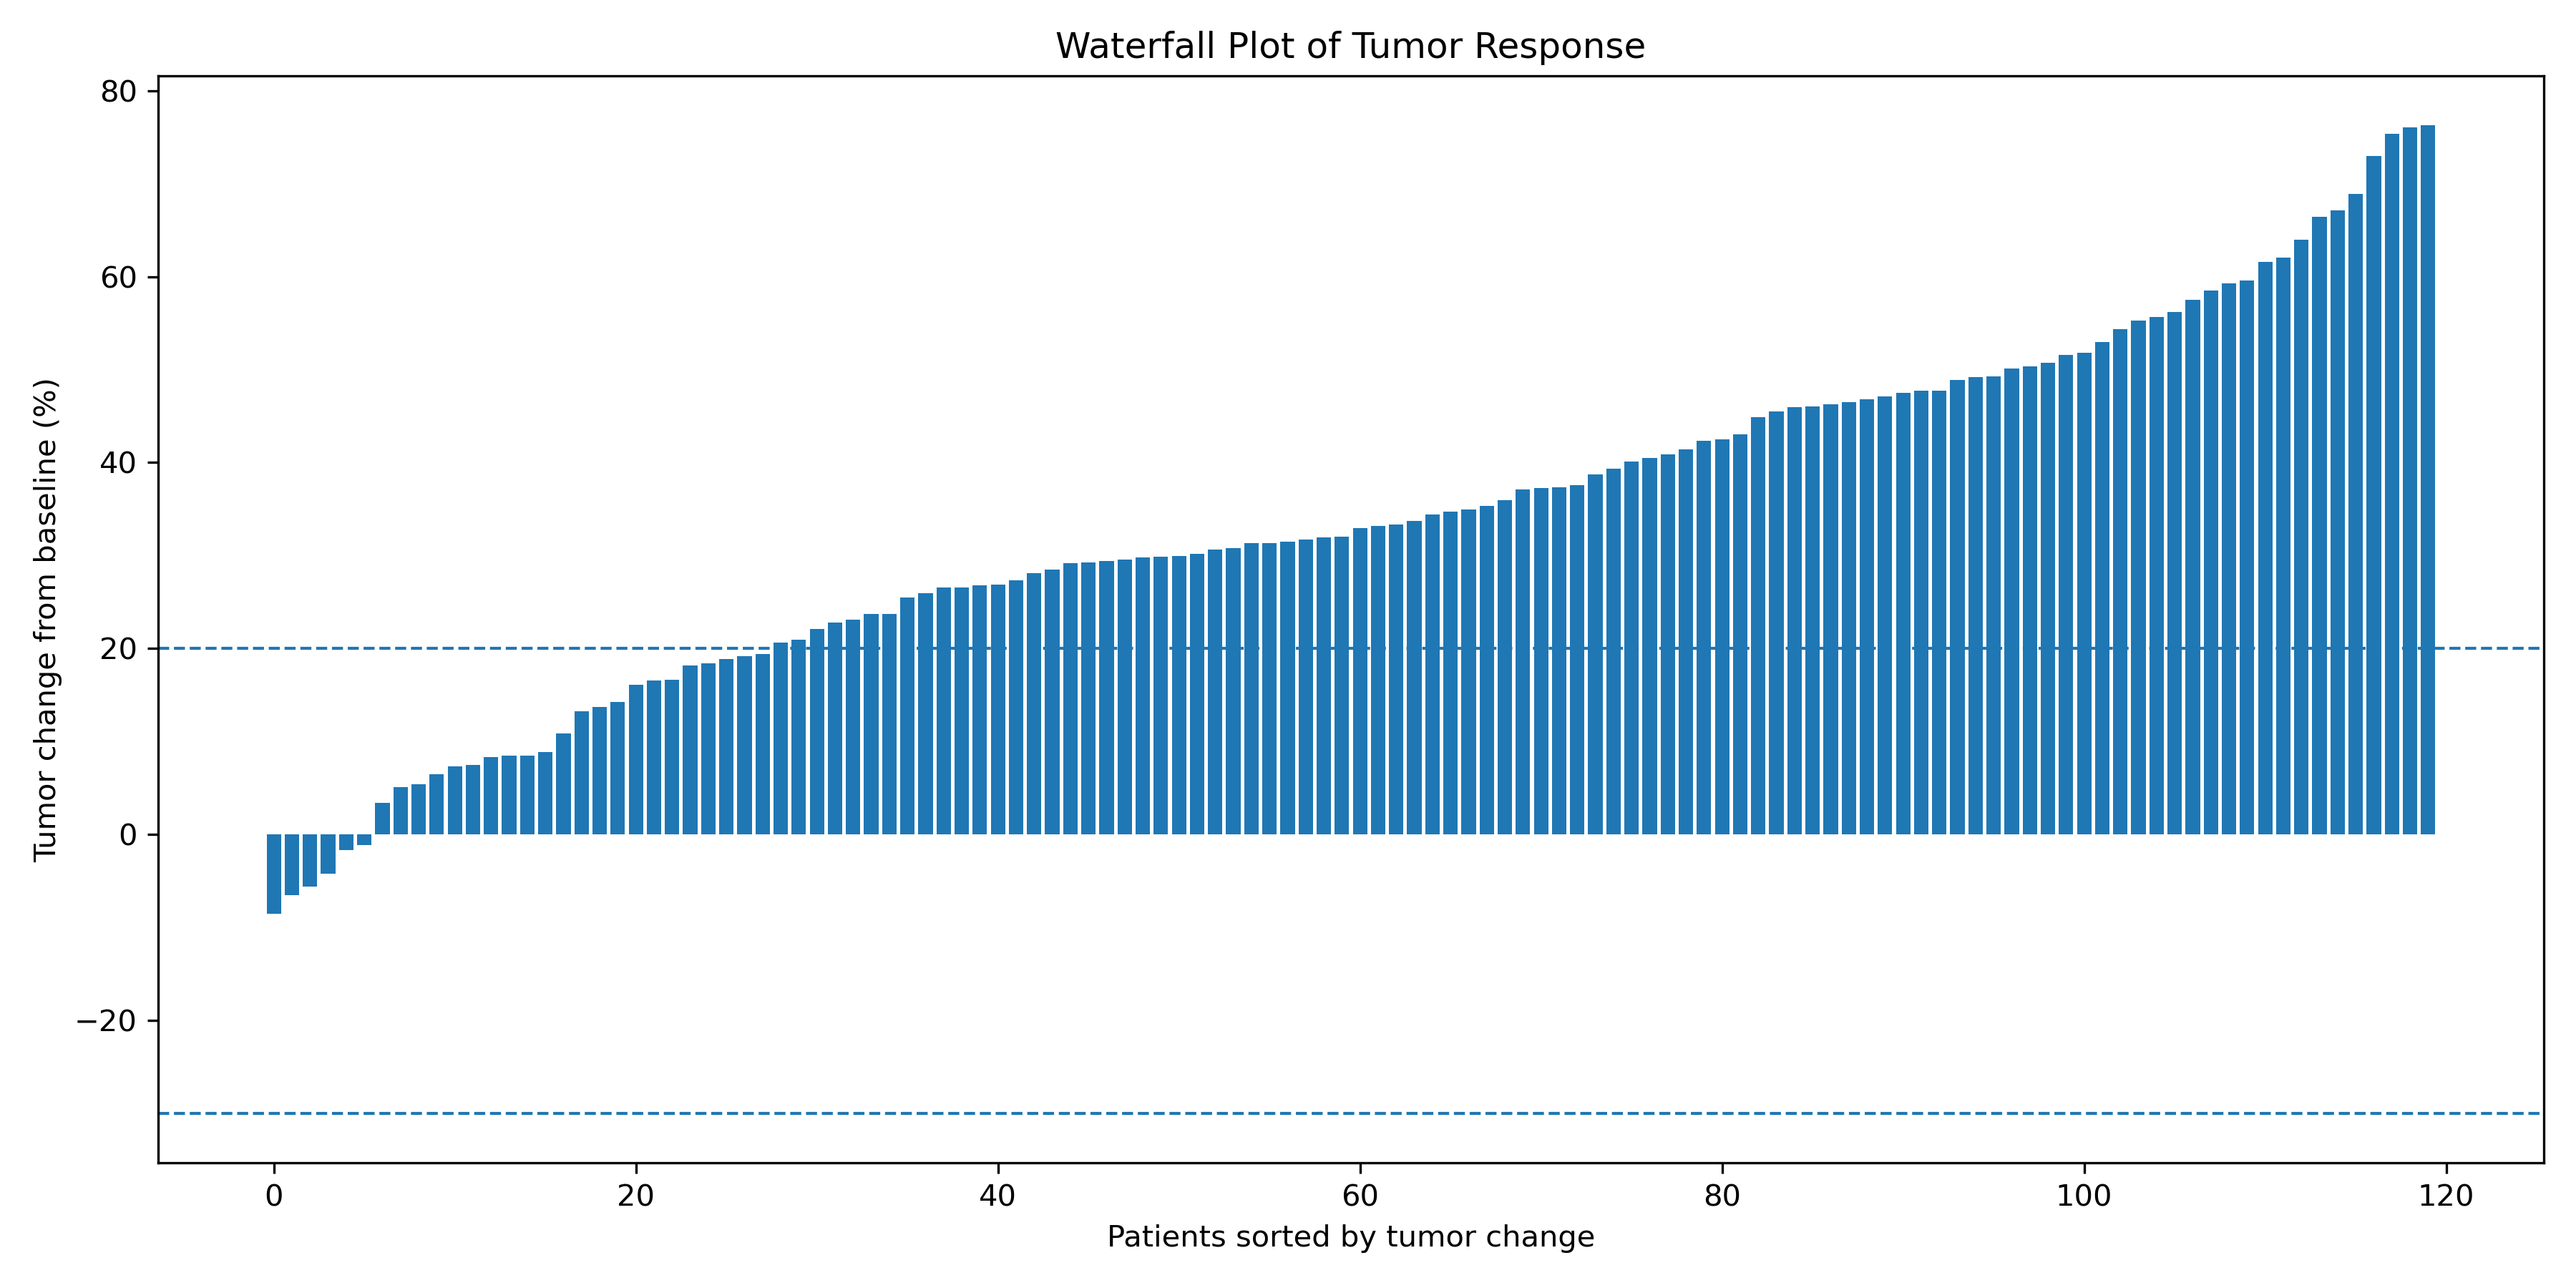

km_curve_dose_group.png


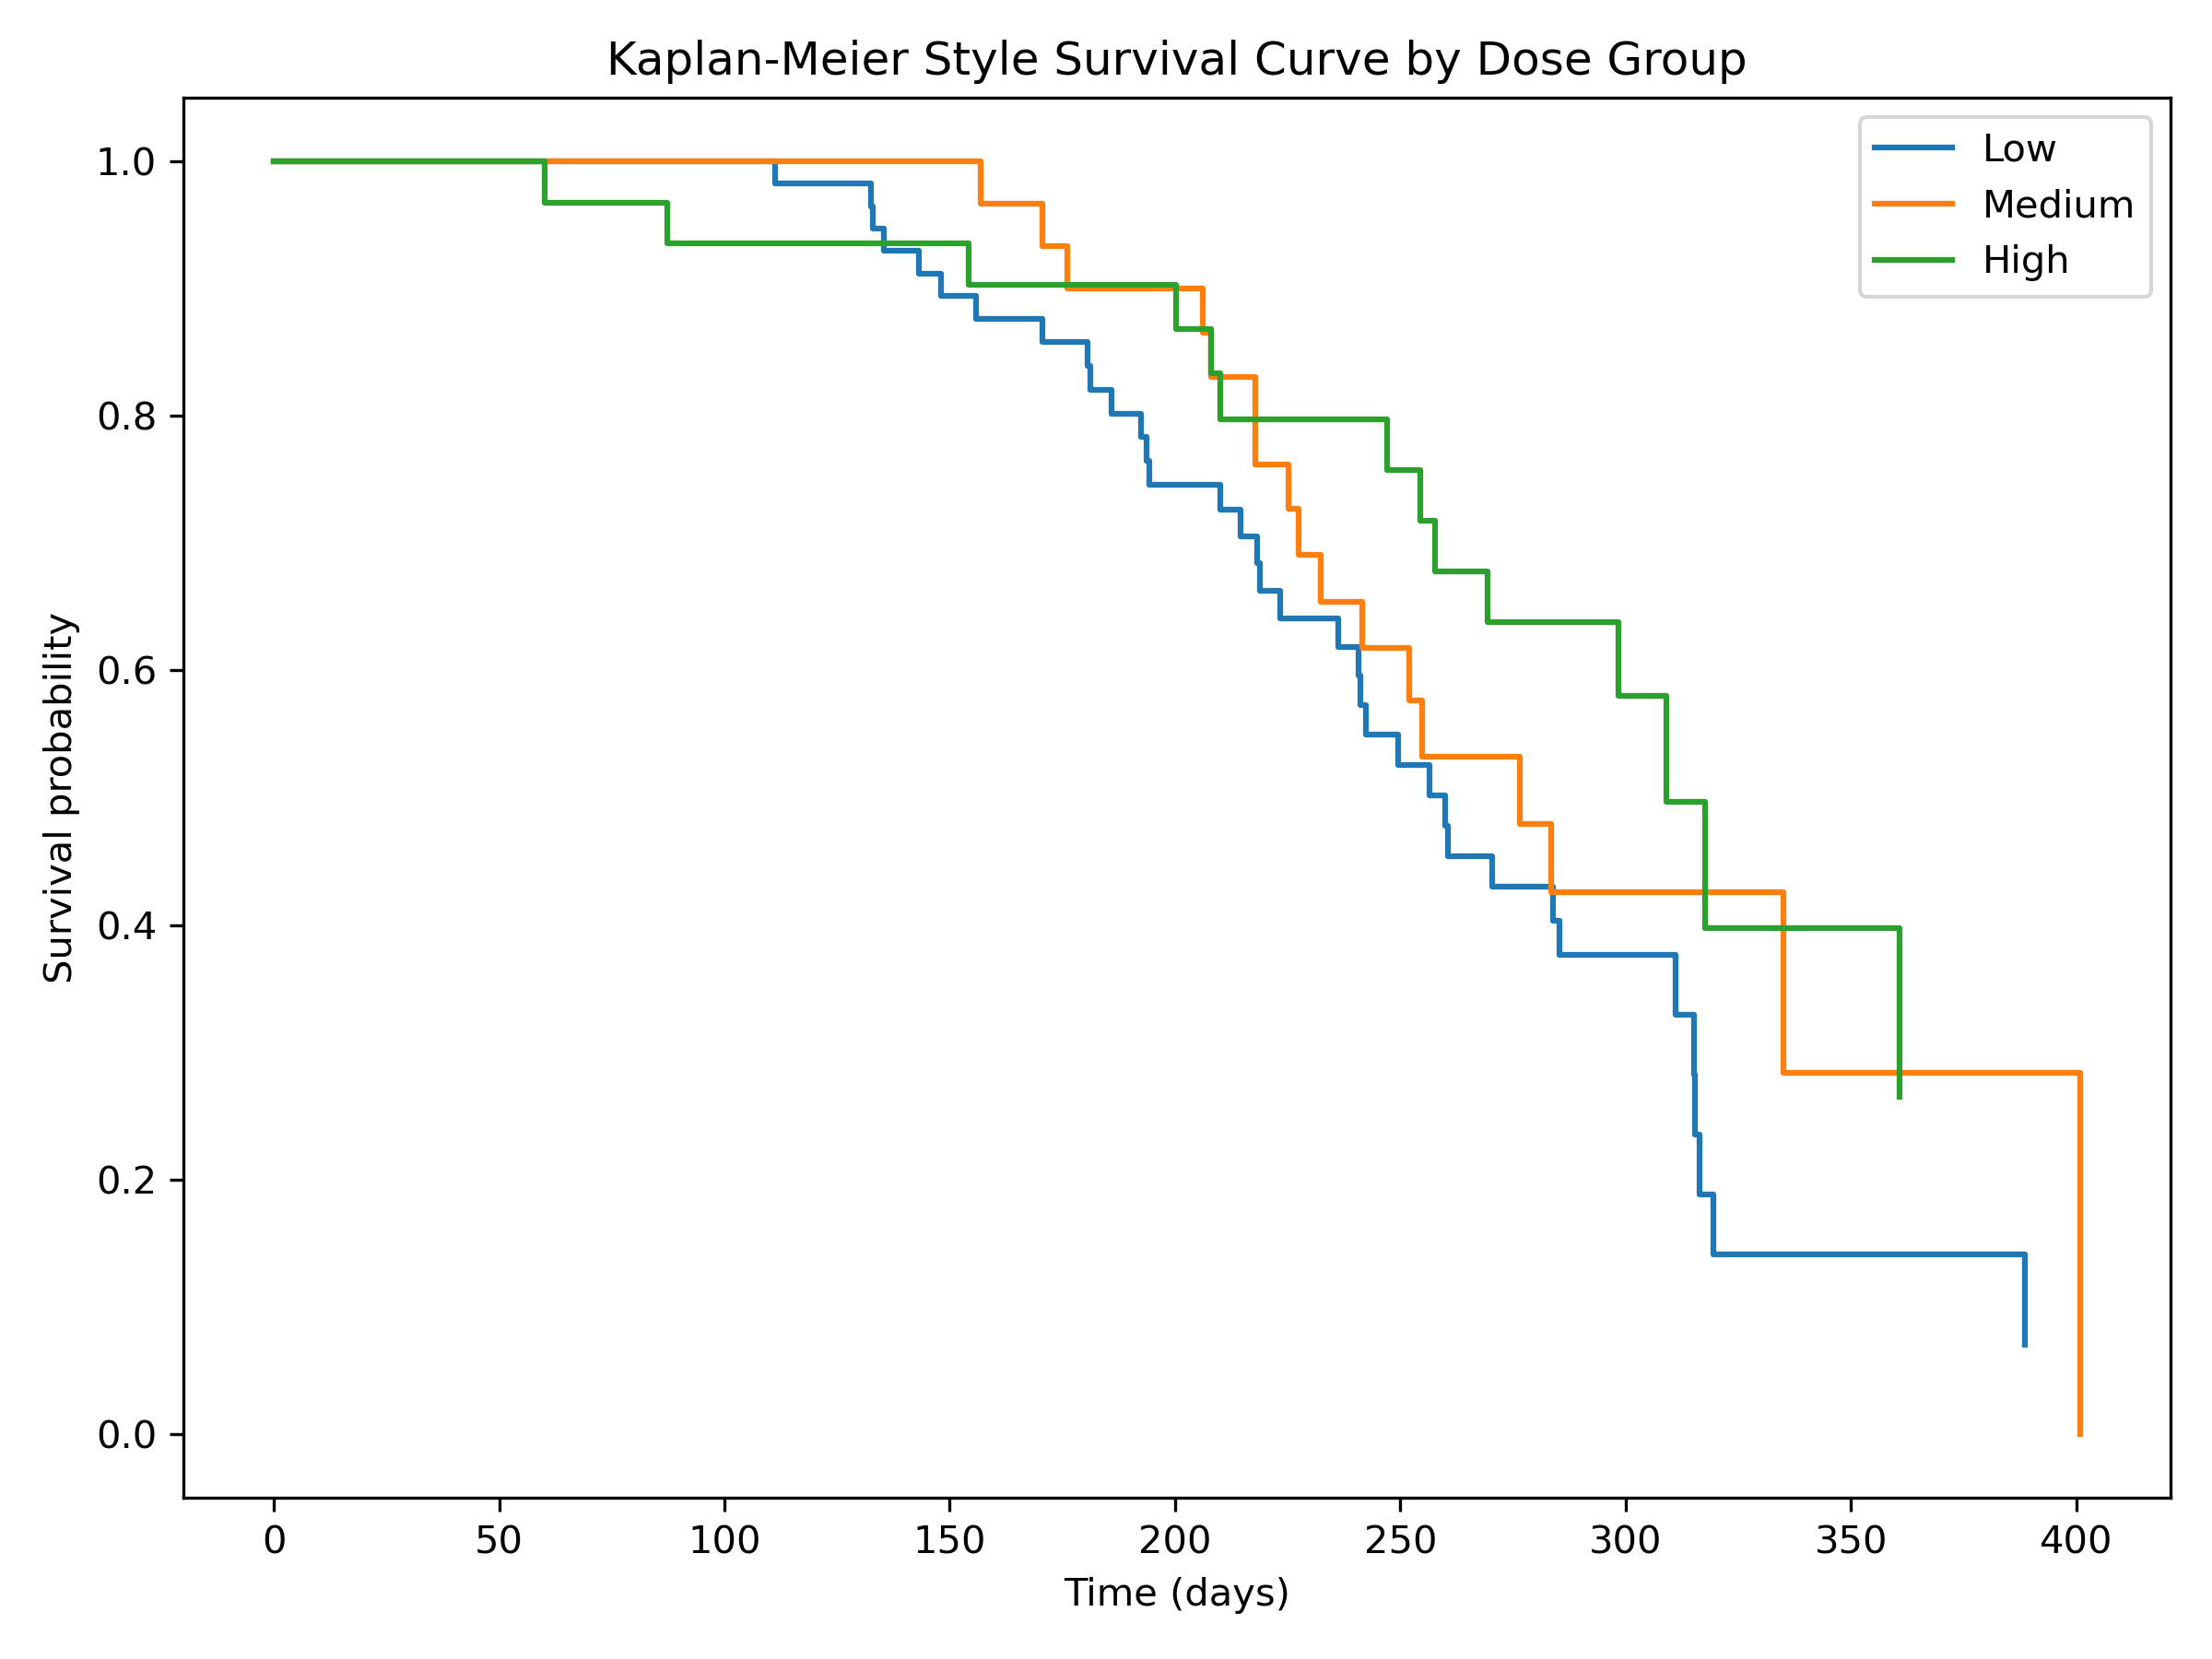

biomarker_vs_tumor_change.png


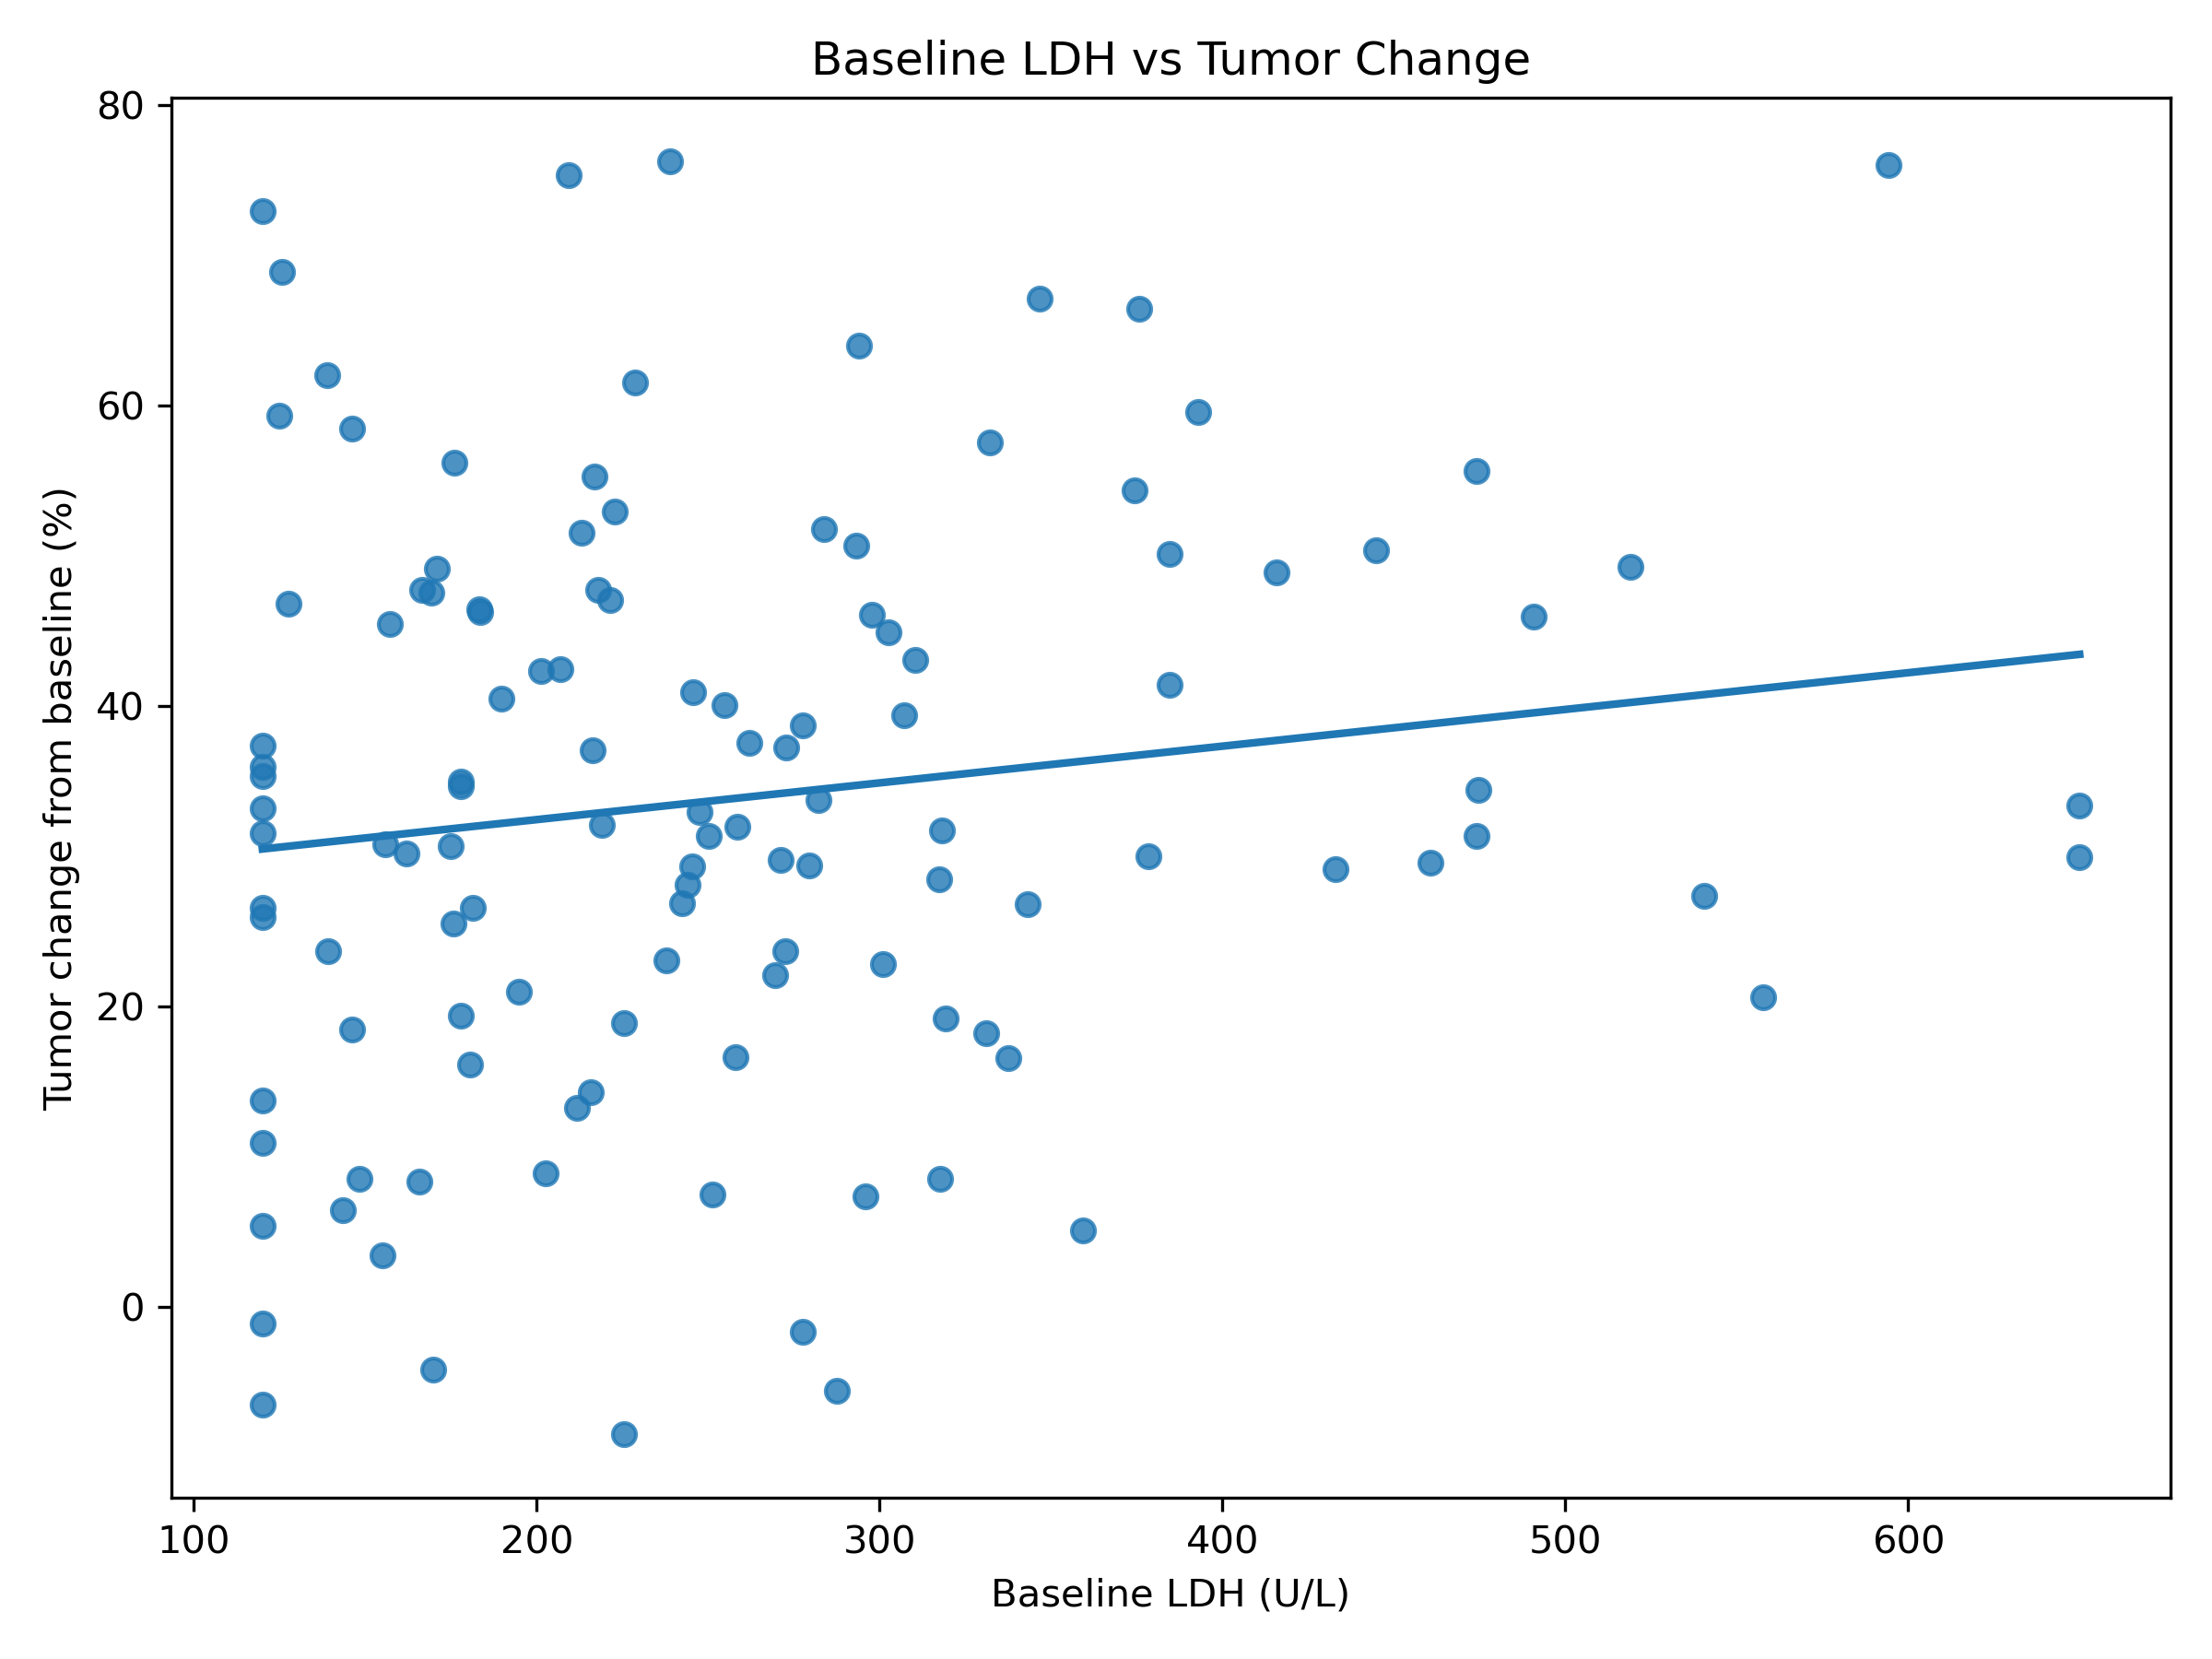

pk_profiles.png


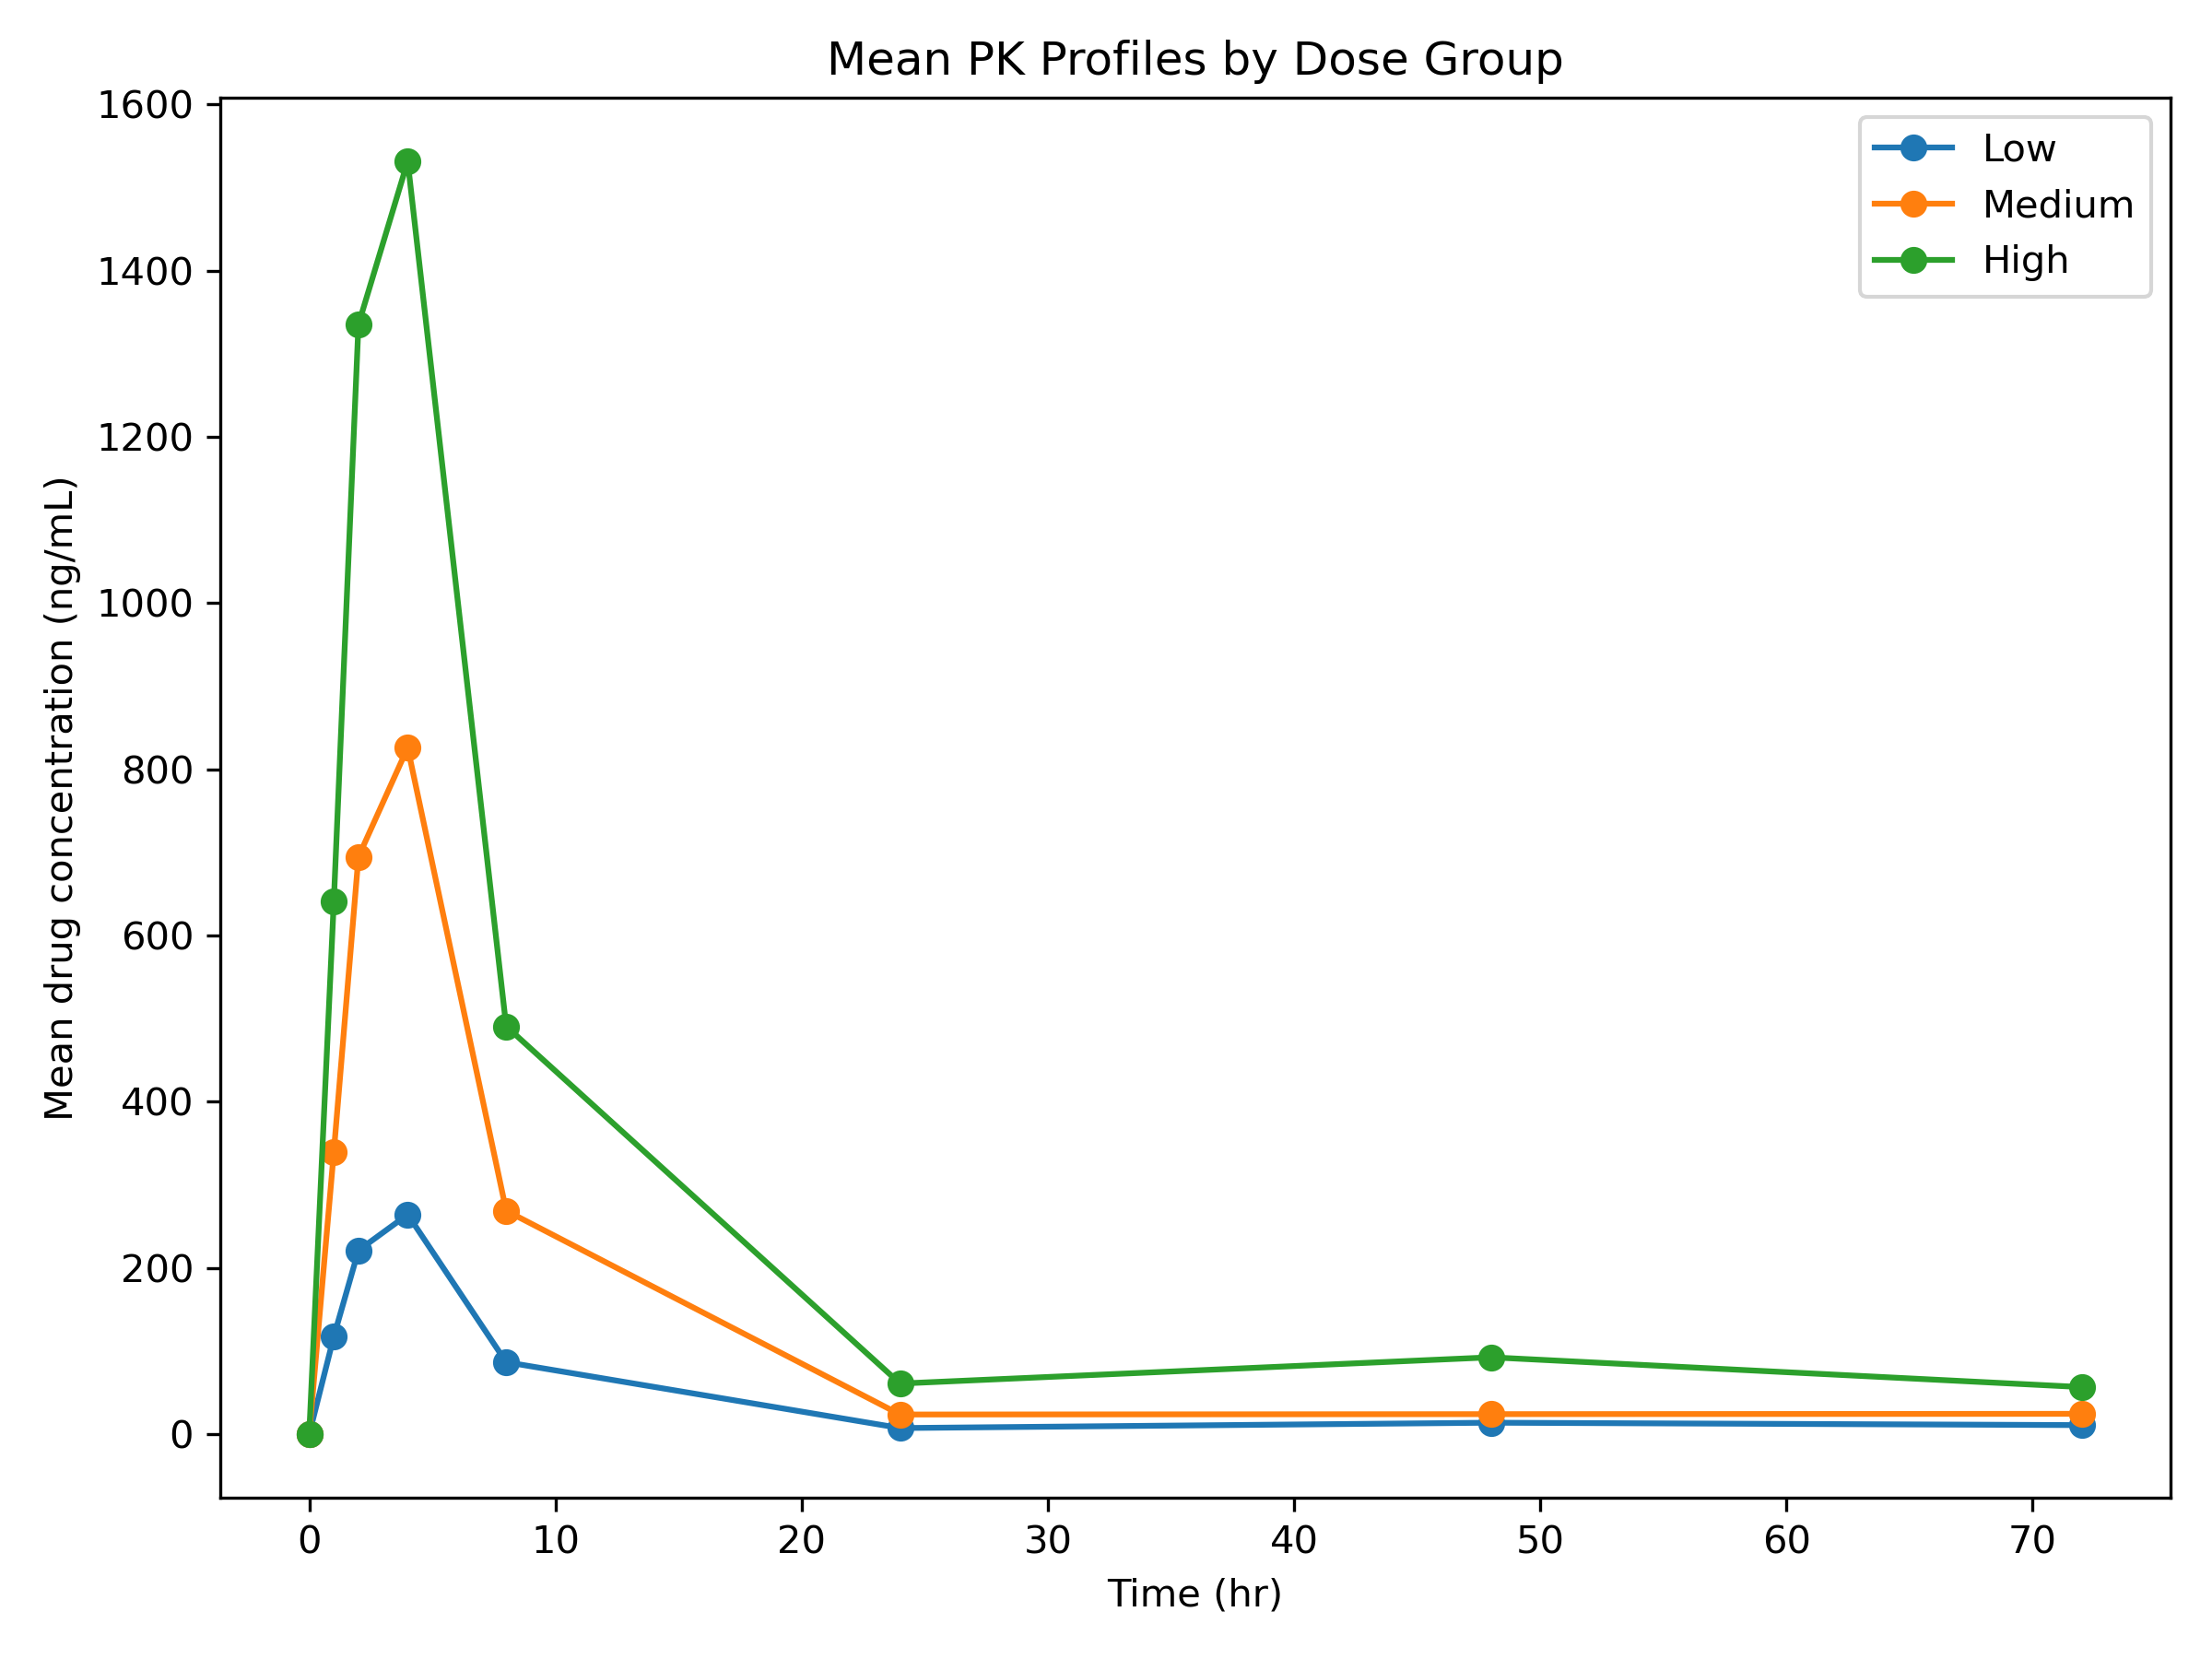

adverse_event_rate_by_dose.png


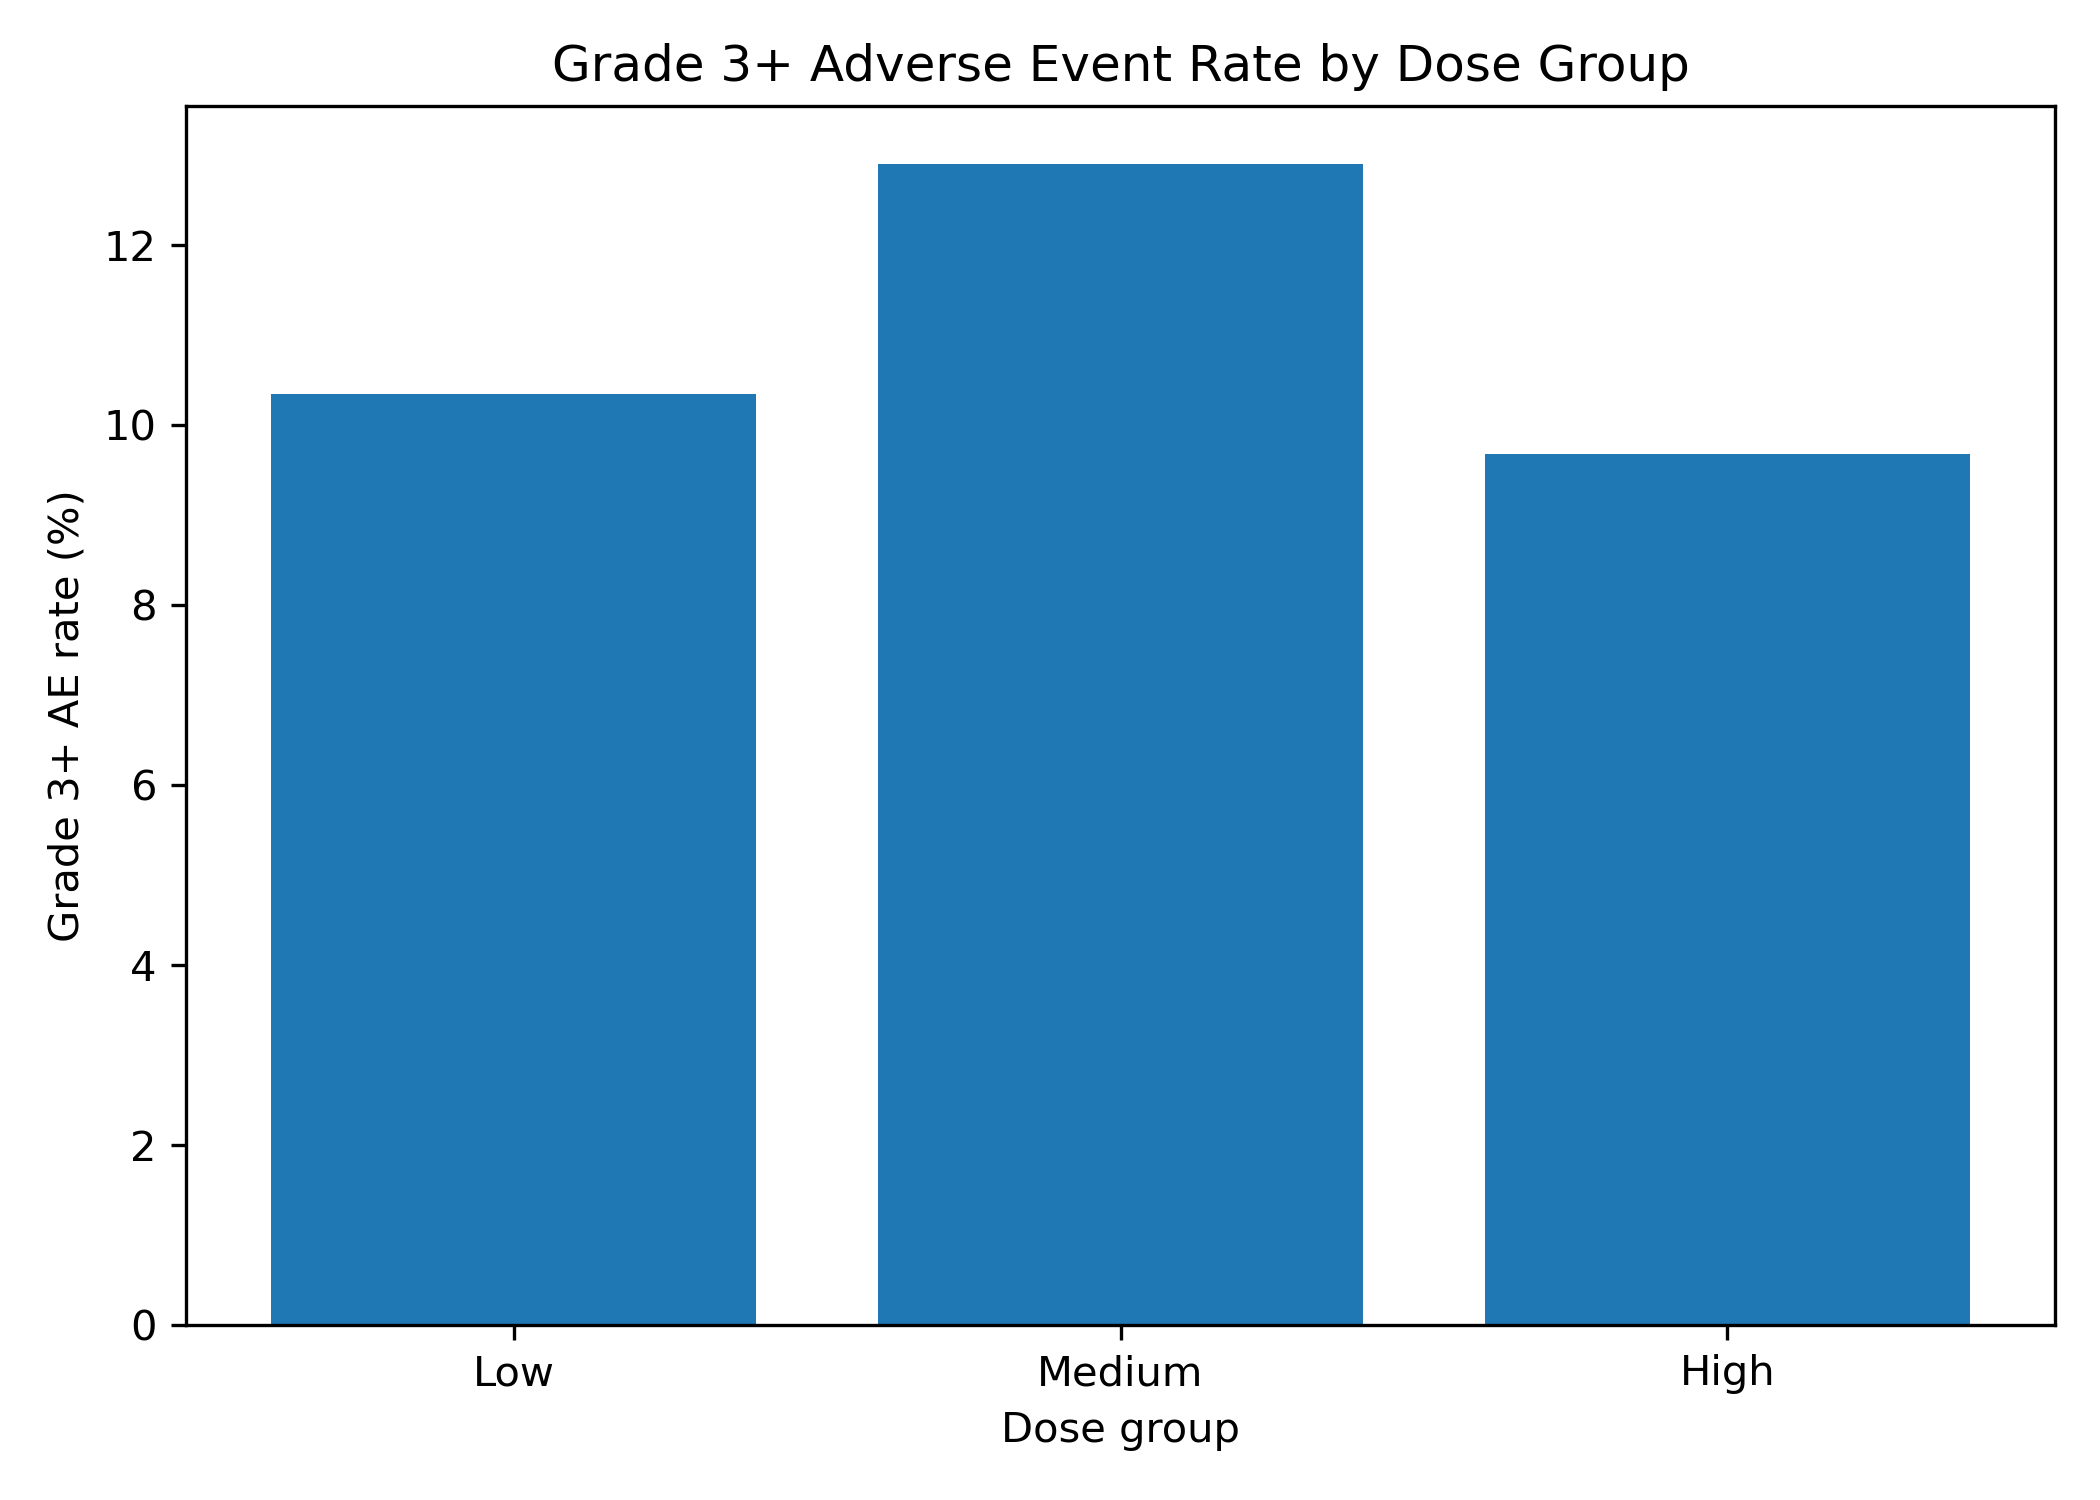

In [18]:
from IPython.display import Image, display

for fig in [
    "waterfall_plot.png",
    "km_curve_dose_group.png",
    "biomarker_vs_tumor_change.png",
    "pk_profiles.png",
    "adverse_event_rate_by_dose.png",
]:
    print(fig)
    display(Image(filename=os.path.join(FIG_DIR, fig)))


## 7. Exploratory modeling

In [20]:
def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    model_df = df.copy()
    model_df["Mutation_Mutant"] = (model_df["Mutation_Status"] == "Mutant").astype(int)
    return model_df


def run_logistic_regression(df: pd.DataFrame) -> str:
    features = ["Dose_mg", "LDH_U_L", "CRP_mg_L", "ctDNA_fraction", "AUC_0_72", "Mutation_Mutant"]
    X = df[features].copy()
    y = df["Responder"].astype(int)

    if y.nunique() < 2:
        return "=== Logistic Regression: Responder ===\nInsufficient class variation to fit model.\n"

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        return "=== Logistic Regression: Responder ===\nInsufficient class variation after split to fit model.\n"

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = model.predict(X_test_scaled)
    auc = roc_auc_score(y_test, probs)

    coef_table = pd.DataFrame({"Feature": features, "Coefficient": model.coef_[0]}).sort_values("Coefficient", ascending=False)

    text = []
    text.append("=== Logistic Regression: Responder ===")
    text.append(f"ROC AUC: {auc:.3f}")
    text.append("")
    text.append("Coefficients:")
    text.append(coef_table.to_string(index=False))
    text.append("")
    text.append("Classification report:")
    text.append(classification_report(y_test, preds, zero_division=0))
    text.append("")
    return "\n".join(text)


def run_random_forest(df: pd.DataFrame) -> str:
    features = ["Dose_mg", "Age", "ECOG", "LDH_U_L", "CRP_mg_L", "ctDNA_fraction", "AUC_0_72", "Cmax", "Mutation_Mutant"]
    X = df[features].copy()
    y = df["Clinical_Benefit"].astype(int)

    if y.nunique() < 2:
        return "=== Random Forest: Clinical Benefit ===\nInsufficient class variation to fit model.\n"

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        return "=== Random Forest: Clinical Benefit ===\nInsufficient class variation after split to fit model.\n"

    model = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_leaf=3)
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)
    auc = roc_auc_score(y_test, probs)

    importance_df = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_}).sort_values("Importance", ascending=False)

    text = []
    text.append("=== Random Forest: Clinical Benefit ===")
    text.append(f"ROC AUC: {auc:.3f}")
    text.append("")
    text.append("Feature importance:")
    text.append(importance_df.to_string(index=False))
    text.append("")
    text.append("Classification report:")
    text.append(classification_report(y_test, preds, zero_division=0))
    text.append("")
    return "\n".join(text)


def run_survival_association(df: pd.DataFrame) -> str:
    df = df.copy()
    df["High_Risk_Biomarker"] = ((df["High_LDH"] == 1) & (df["High_CRP"] == 1)).astype(int)

    summary = (
        df.groupby(["Dose_Group", "High_Risk_Biomarker"])
        .agg(
            N=("Patient_ID", "count"),
            Median_Survival_days=("Survival_Time_days", "median"),
            Event_Rate=("Event", "mean"),
        )
        .reset_index()
    )
    summary["Event_Rate"] = (summary["Event_Rate"] * 100).round(1)

    text = []
    text.append("=== Exploratory Survival Association Summary ===")
    text.append("Grouped by Dose Group and High-Risk Biomarker Status")
    text.append("")
    text.append(summary.to_string(index=False))
    text.append("")
    return "\n".join(text)


model_df = encode_features(analysis)

results_text = "\n\n".join([
    run_logistic_regression(model_df),
    run_random_forest(model_df),
    run_survival_association(model_df),
])

with open(os.path.join(MODEL_DIR, "model_results.txt"), "w", encoding="utf-8") as f:
    f.write(results_text)

print(results_text)


=== Logistic Regression: Responder ===
Insufficient class variation to fit model.


=== Random Forest: Clinical Benefit ===
ROC AUC: 0.851

Feature importance:
        Feature  Importance
           Cmax    0.189498
       CRP_mg_L    0.182506
       AUC_0_72    0.174392
 ctDNA_fraction    0.119430
        LDH_U_L    0.105306
            Age    0.092137
        Dose_mg    0.066719
           ECOG    0.059017
Mutation_Mutant    0.010996

Classification report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        23
           1       1.00      0.14      0.25         7

    accuracy                           0.80        30
   macro avg       0.90      0.57      0.57        30
weighted avg       0.84      0.80      0.74        30



=== Exploratory Survival Association Summary ===
Grouped by Dose Group and High-Risk Biomarker Status

Dose_Group  High_Risk_Biomarker  N  Median_Survival_days  Event_Rate
      High                    0 23 

## 8. Command-line equivalents

If you later split this notebook back into scripts, the run order is:

```bash
python scripts/01_simulate_data.py
python scripts/02_build_analysis_dataset.py
python scripts/03_generate_tables.py
python scripts/04_visualize.py
python scripts/05_modeling.py
```